#### Employee Attrition Prediction - Using ANN Model

This project aims to build an Artificial Neural Network Model to predict whether an employee is likely to leave the company (Exited = 1), enabling the HR department to implement proactive retention strategies and reduce turnover-related costs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, precision_recall_curve
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import joblib
import os
import logging
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger('churn_model')

# Create model directory
MODEL_DIR = "churn_model"
if not os.path.exists(MODEL_DIR):
    os.makedirs(MODEL_DIR)

In [4]:
# function to load and explore the data
def load_explore_data(filepath):
    """
    Load and explore the data for the churn model
    
    Args:
        Path to the csv file
    """
    logger.info("Loading data from %s", filepath)
    df = pd.read_csv(filepath)
    
    # Data exploration
    logger.info("Dataset shape: %s", df.shape)
    
    # Check for missing values
    missing_values = df.isnull().sum()
    logger.info("Missing values in the dataset: \n%s", missing_values)
    
    # Check for class imbalance
    class_distribution = df["Exited"].value_counts(normalize=True)
    logger.info("Class distribution of the target feature: \n%s", class_distribution)
    
    
    return df


dataset = load_explore_data("Churn_Modelling.csv")

2025-05-02 11:18:10,999 - churn_model - INFO - Loading data from Churn_Modelling.csv
2025-05-02 11:18:11,062 - churn_model - INFO - Dataset shape: (10000, 14)
2025-05-02 11:18:11,073 - churn_model - INFO - Missing values in the dataset: 
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64
2025-05-02 11:18:11,079 - churn_model - INFO - Class distribution of the target feature: 
Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


    The data is imbalanced. Not Exited (0) = 79.63% while Exited (1) = 20.37%. 
    Notably, there are no missing values

In [5]:
# function to preprocess and feature engineer the data

def data_preprocess(data, test_size = 0.2, val_size=0.25):
    """
    Preprocesses and applies feature engineering to the data
    """
    # Assign independent features to X and dependent features to y - We omit features such as RowNumber, CustomerId, and Surname
    X = data.iloc[:, 3:13]
    y = data.iloc[:, 13]
    
    # Create dummy variables for the categorical features present in the data - Geography and Gender
    geography = pd.get_dummies(X["Geography"], drop_first=True)
    gender = pd.get_dummies(X["Gender"], drop_first=True)
    
    # Concatenate with original data frame
    X = pd.concat([X, geography, gender], axis=1)
    
    # Drop the original categorical features
    X = X.drop(["Geography", "Gender"], axis=1)
    
    # Split the data into train and test sets
    X_train_val, X_test, y_train_val, y_test = train_test_split(X, y,
                                                                test_size=test_size, random_state=234, stratify=y)
    
    # Split the train data into a train and validation set
    X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val,
                                                     test_size=val_size, random_state=234, stratify=y_train_val)
    
    # feature scaling
    sc = StandardScaler()
    X_train_scaled = sc.fit_transform(X_train)
    X_val_scaled = sc.transform(X_val)
    X_test_scaled = sc.transform(X_test)
    
    # Save the scaler for later use in production
    joblib.dump(sc, os.path.join(MODEL_DIR, 'scaler.pkl'))
    
    # Save feature names for model interpretability
    feature_names = list(X.columns)
    with open(os.path.join(MODEL_DIR, 'feature_names.txt'), 'w') as f:
        for feature in feature_names:
            f.write(f"{feature}\n")
            
    logger.info("Data preprocessing completed!")
    
    return X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test, feature_names

X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test, feature_names = data_preprocess(dataset)

2025-05-02 11:18:15,021 - churn_model - INFO - Data preprocessing completed!


    In the above preprocessing, we omit features such as RowNumber CustomerId, and Surname since they won't add any useful info to the model

In [6]:
# Function to build and compile the artificial neural network model

def build_model(input_dim, optimizer = "adam", learning_rate = 0.001):
    """
    Build and compile the neural network model
    
    Args:
        input_dim: dimensions of the data - number of input features
        optimizer: optimizer to use
        learning_rate: learning rate for the optimizer
        
    Returns:
        Compiled keras model
    """
    logger.info("Compiling the ANN")
    # Initialize the ANN
    model = Sequential()
    
    # Adding the input layer and the first hidden layer
    model.add(Dense(units=64, kernel_initializer="he_uniform", activation="relu", input_dim=input_dim))
    model.add(Dropout(0.3))
    
    # Second hidden layer
    model.add(Dense(units=32, kernel_initializer="he_uniform", activation="relu"))
    model.add(Dropout(0.2))
    
    # Output layer
    model.add(Dense(units=1, kernel_initializer="glorot_uniform", activation="sigmoid"))
    
    # compile the model
    if optimizer.lower()=="adam":
        opt = Adam(learning_rate=learning_rate)
    else:
        opt = optimizer
    
    model.compile(optimizer=opt, loss="binary_crossentropy", metrics=["accuracy"])
    
    logger.info("Compiled model successfully")
    
    return model

model = build_model(input_dim=X_train_scaled.shape[1])

2025-05-02 11:18:18,891 - churn_model - INFO - Compiling the ANN
2025-05-02 11:18:19,169 - churn_model - INFO - Compiled model successfully


In [7]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                768       
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 2,881
Trainable params: 2,881
Non-trainable params: 0
_________________________________________________________________


In [7]:
# Function to train the model

def train_model(X_train, y_train, X_val, y_val, model, batch_size=32, epochs=100, patience=10):
    """
    Train the neural network model with early stopping and model checkpointing
    
    Args:
        X_train: Training data
        y_train: Training target
        X_val: Validation data
        y_val: Validation target
        batch_size: Batch size for training
        epochs: Maximum number of epochs
        patience: Patience for early stopping
        
    Returns:
        Trained model
    """
    logger.info("Building and training the model")
    
    # Define callbacks for training
    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True,
        verbose=1
    )
    
    checkpoint = ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, 'best_model.h5'),
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=0.0001,
        verbose=1
    )
    
    # Print model summary
    model.summary()
    
    # Train the model
    history = model.fit(
        X_train, y_train,
        validation_data = (X_val, y_val),
        batch_size = batch_size,
        epochs = epochs,
        callbacks = [early_stopping, checkpoint, reduce_lr],
        verbose=1
    )
    
    # Load the best model
    model = load_model(os.path.join(MODEL_DIR, 'best_model.h5'))
    
    return model, history

model, history = train_model(X_train_scaled, y_train, X_val_scaled, y_val, model)

2025-05-02 11:18:37,399 - churn_model - INFO - Building and training the model


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                768       
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 2,881
Trainable params: 2,881
Non-trainable params: 0
_________________________________________________________________
Epoch 1/100
179/188 [===========================>..] -

Epoch 23/100
188/188 [==============================] - ETA: 0s - loss: 0.3637 - accuracy: 0.8508
Epoch 23: val_loss improved from 0.33901 to 0.33803, saving model to churn_model\best_model.h5
188/188 [==============================] - 1s 6ms/step - loss: 0.3637 - accuracy: 0.8508 - val_loss: 0.3380 - val_accuracy: 0.8705 - lr: 0.0010
Epoch 24/100
183/188 [============================>.] - ETA: 0s - loss: 0.3596 - accuracy: 0.8472
Epoch 24: val_loss improved from 0.33803 to 0.33706, saving model to churn_model\best_model.h5
188/188 [==============================] - 1s 7ms/step - loss: 0.3592 - accuracy: 0.8477 - val_loss: 0.3371 - val_accuracy: 0.8680 - lr: 0.0010
Epoch 25/100
186/188 [============================>.] - ETA: 0s - loss: 0.3632 - accuracy: 0.8474
Epoch 25: val_loss did not improve from 0.33706
188/188 [==============================] - 1s 5ms/step - loss: 0.3630 - accuracy: 0.8478 - val_loss: 0.3376 - val_accuracy: 0.8680 - lr: 0.0010
Epoch 26/100
187/188 [==============

In [8]:
# Function to evaluate the model

def evaluate_model(model, X_test, y_test, threshold = 0.5):
    """
    Evaluate the model on test data
    
    Args:
        model: Trained model
        X_test: Test data set
        y_test: Test target
        threshold: Classification threshold
    """
    logger.info("Evaluating model performance")
    
    # predict probabilities
    y_pred_proba = model.predict(X_test)
    
    # Convert probabilities to binary predictions using threshold
    y_pred = (y_pred_proba > threshold).astype(int)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Classification report
    cr = classification_report(y_test, y_pred)
    
    # Log metrics
    logger.info(f"Accuracy: {accuracy:.4f}")
    logger.info(f"Precision: {precision:.4f}")
    logger.info(f"Recall: {recall:.4f}")
    logger.info(f"F1 Score: {f1:.4f}")
    logger.info(f"ROC AUC: {roc_auc:.4f}")
    logger.info(f"Confusion Matrix:\n{cm}")
    logger.info(f"Classification Report:\n{cr}")
    
    # Save metrics to file
    with open(os.path.join(MODEL_DIR, 'model_metrics.txt'), 'w') as f:
        f.write(f"Accuracy: {accuracy:.4f}\n")
        f.write(f"Precision: {precision:.4f}\n")
        f.write(f"Recall: {recall:.4f}\n")
        f.write(f"F1 Score: {f1:.4f}\n")
        f.write(f"ROC AUC: {roc_auc:.4f}\n")
        f.write(f"Confusion Matrix:\n{cm}\n")
        f.write(f"Classification Report:\n{cr}\n")
    
    metrics = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'confusion_matrix': cm,
        'classification_report': cr,
        'y_pred_proba': y_pred_proba,
        'y_pred': y_pred
    }
    
    return metrics


metrics = evaluate_model(model, X_test_scaled, y_test)

2025-05-02 11:19:56,537 - churn_model - INFO - Evaluating model performance


63/63 [==============================] - 0s 3ms/step


2025-05-02 11:19:57,131 - churn_model - INFO - Accuracy: 0.8655
2025-05-02 11:19:57,133 - churn_model - INFO - Precision: 0.7875
2025-05-02 11:19:57,135 - churn_model - INFO - Recall: 0.4644
2025-05-02 11:19:57,137 - churn_model - INFO - F1 Score: 0.5842
2025-05-02 11:19:57,142 - churn_model - INFO - ROC AUC: 0.7162
2025-05-02 11:19:57,145 - churn_model - INFO - Confusion Matrix:
[[1542   51]
 [ 218  189]]
2025-05-02 11:19:57,148 - churn_model - INFO - Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.46      0.58       407

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000



    The model's performance is evaluated on the test set. 
    
**Interpretation**

 - The model achieves a high overall accuracy of 86.6%, driven largely by strong performance on predicting employees who stay.

 - Precision for predicting exits (78.8%) is strong — most employees flagged as "likely to exit" do eventually leave. When the model predicts an employee will leave, it is correct 78.8% of the time.

- However, recall for exits (46.4%) is moderate. Over half of actual leavers are not identified, which could limit the effectiveness of early intervention strategies. The model only identifies 45.95% of all exits.

- F1 Score (58.4%) reflects the tradeoff between precision and recall in this imbalanced classification task.

- The ROC AUC score (71.6%) indicates that the model has reasonable ability to distinguish between stayers and leavers.

2025-05-02 11:20:02,826 - churn_model - INFO - Generating visualizations
2025-05-02 11:20:05,158 - churn_model - INFO - Visualizations saved to churn_model\visualizations


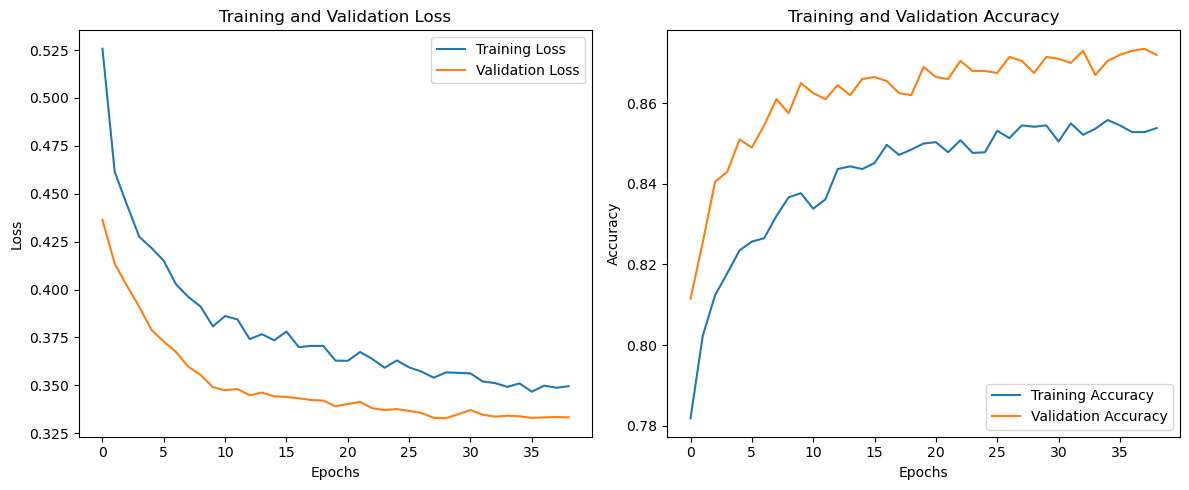

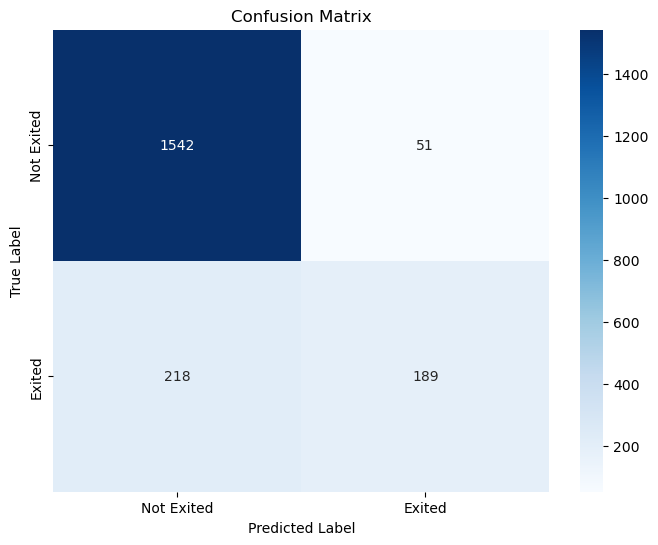

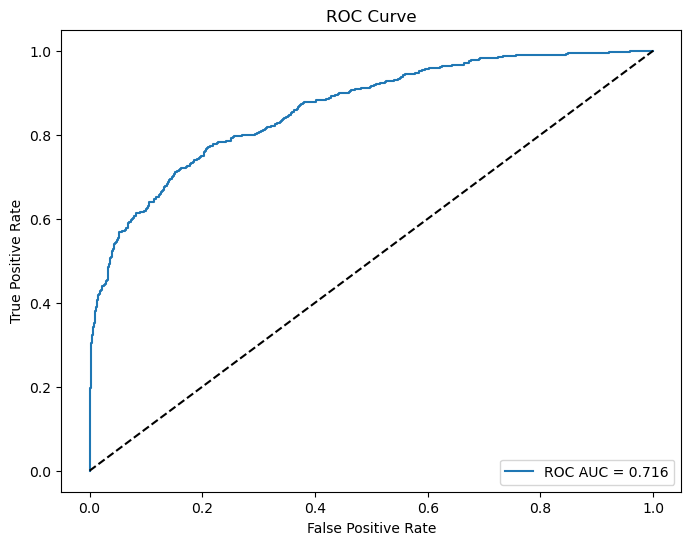

In [9]:
# Function to visualize model results

def visualize_results(history, metrics, feature_names, X_train, y_train, threshold=0.5):
    """
    Visualize the model training and evaluation results
    
    Args:
        history: Training history
        metrics: Evaluation metrics
        feature_names: Names of features
        X_train: Training features for calculating feature importance
        y_train: Training target
    """
    logger.info("Generating visualizations")
    
    # Create a directory for visualizations
    VIZ_DIR = os.path.join(MODEL_DIR, 'visualizations')
    if not os.path.exists(VIZ_DIR):
        os.makedirs(VIZ_DIR)
        
    
     # Plot training history
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_DIR, 'training_history.png'))
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(metrics['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Exited', 'Exited'],
                yticklabels=['Not Exited', 'Exited'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.savefig(os.path.join(VIZ_DIR, 'confusion_matrix.png'))
    
    # Plot ROC curve
    fpr, tpr, _ = roc_curve(metrics['y_test'], metrics['y_pred_proba'])
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC AUC = {metrics["roc_auc"]:.3f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.savefig(os.path.join(VIZ_DIR, 'roc_curve.png'))
    
    logger.info("Visualizations saved to %s", VIZ_DIR)

    
metrics["y_test"] = y_test
visualize_results(history, metrics, feature_names, X_train_scaled, y_train)  

In [22]:
# Function to create a prediction pipeline - can be used to make predictions on new data
# Handles data preprocessing and feature engineering

def create_prediction_pipeline(model, threshold=0.5):
    """
    Create a function for making predictions in production.
    
    Args:
        model: Trained model
        threshold: Classification threshold
    
    Returns:
        Prediction function
    """
    # Load the scaler
    scaler = joblib.load(os.path.join(MODEL_DIR, 'scaler.pkl'))
    
    def predict(data):
        """
        Make predictions on new data.
        
        Args:
            data: DataFrame with the same features as the training data
        
        Returns:
            Predictions (class labels) and probabilities
        """
        # Preprocess the data
        # Handle categorical variables if present
        if 'Geography' in data.columns:
            geography = pd.get_dummies(data["Geography"], drop_first=True)
            data = pd.concat([data, geography], axis=1)
            data = data.drop(["Geography"], axis=1)
        
        if 'Gender' in data.columns:
            gender = pd.get_dummies(data["Gender"], drop_first=True)
            data = pd.concat([data, gender], axis=1)
            data = data.drop(["Gender"], axis=1)
        
        # Scale the features
        data_scaled = scaler.transform(data)
        
        # Make predictions
        probabilities = model.predict(data_scaled)
        predictions = (probabilities > threshold).astype(int)
        
        return predictions, probabilities
    
    # Save the prediction function
    joblib.dump(predict, os.path.join(MODEL_DIR, 'predict_function.pkl'))
    
    return predict

    Below code demonstrates how to tune an Artificial Neural Network model. We can use the best parameters to rebuild and train the final model on a combined training and validation set, and evaluate on the test set.

In [23]:
# Function for hyperparameter tuning
def tune_hyperparameters(X_train, y_train, X_val, y_val, input_dim):
    """
    Perform hyperparameter tuning for the neural network.
    
    Args:
        X_train: Training features
        y_train: Training target
        X_val: Validation features
        y_val: Validation target
        input_dim: Number of input features
        
    Returns:
        Best hyperparameters
    """
    logger.info("Starting hyperparameter tuning")
    
    # Define hyperparameter search space
    param_grid = {
        'learning_rate': [0.01, 0.001, 0.0001],
        'batch_size': [16, 32, 64],
        'dropout_rate': [0.2, 0.3, 0.4],
        'units_first_layer': [32, 64, 128]
    }
    
    best_val_loss = float('inf')
    best_params = {}
    
    # Simple grid search implementation (for demonstration)
    for lr in param_grid['learning_rate']:
        for bs in param_grid['batch_size']:
            for dr in param_grid['dropout_rate']:
                for units in param_grid['units_first_layer']:
                    logger.info(f"Trying lr={lr}, bs={bs}, dr={dr}, units={units}")
                    
                    # Build model with current hyperparameters
                    model = Sequential()
                    model.add(Dense(units=units, kernel_initializer='he_uniform', activation='relu', input_dim=input_dim))
                    model.add(BatchNormalization())
                    model.add(Dropout(dr))
                    model.add(Dense(units=units//2, kernel_initializer='he_uniform', activation='relu'))
                    model.add(BatchNormalization())
                    model.add(Dropout(dr))
                    model.add(Dense(units=1, kernel_initializer='glorot_uniform', activation='sigmoid'))
                    
                    opt = Adam(learning_rate=lr)
                    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
                    
                    # Train with early stopping
                    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
                    
                    history = model.fit(
                        X_train, y_train,
                        validation_data=(X_val, y_val),
                        batch_size=bs,
                        epochs=20,  # Reduced epochs for faster tuning
                        callbacks=[early_stopping],
                        verbose=0
                    )
                    
                    # Get validation loss
                    val_loss = min(history.history['val_loss'])
                    
                    # Update best parameters if better
                    if val_loss < best_val_loss:
                        best_val_loss = val_loss
                        best_params = {
                            'learning_rate': lr,
                            'batch_size': bs,
                            'dropout_rate': dr,
                            'units_first_layer': units
                        }
    
    logger.info(f"Best parameters: {best_params}")
    logger.info(f"Best validation loss: {best_val_loss}")
    
    # Save best hyperparameters
    with open(os.path.join(MODEL_DIR, 'best_hyperparameters.txt'), 'w') as f:
        for param, value in best_params.items():
            f.write(f"{param}: {value}\n")
    
    return best_params

tune_hyperparameters(X_train_scaled, y_train, X_val_scaled, y_val, input_dim=X_train_scaled.shape[1])

2025-05-02 06:20:36,085 - churn_model - INFO - Starting hyperparameter tuning
2025-05-02 06:20:36,088 - churn_model - INFO - Trying lr=0.01, bs=16, dr=0.2, units=32
2025-05-02 06:21:04,760 - churn_model - INFO - Trying lr=0.01, bs=16, dr=0.2, units=64
2025-05-02 06:21:33,692 - churn_model - INFO - Trying lr=0.01, bs=16, dr=0.2, units=128
2025-05-02 06:21:57,502 - churn_model - INFO - Trying lr=0.01, bs=16, dr=0.3, units=32
2025-05-02 06:22:17,723 - churn_model - INFO - Trying lr=0.01, bs=16, dr=0.3, units=64
2025-05-02 06:22:40,172 - churn_model - INFO - Trying lr=0.01, bs=16, dr=0.3, units=128
2025-05-02 06:23:08,512 - churn_model - INFO - Trying lr=0.01, bs=16, dr=0.4, units=32
2025-05-02 06:23:32,727 - churn_model - INFO - Trying lr=0.01, bs=16, dr=0.4, units=64
2025-05-02 06:24:02,484 - churn_model - INFO - Trying lr=0.01, bs=16, dr=0.4, units=128
2025-05-02 06:24:25,952 - churn_model - INFO - Trying lr=0.01, bs=32, dr=0.2, units=32
2025-05-02 06:24:45,855 - churn_model - INFO - Tr

{'learning_rate': 0.01,
 'batch_size': 32,
 'dropout_rate': 0.3,
 'units_first_layer': 64}

**If we were to use above tuned model, we would first concatenate the training and validation sets:**

    # Concatenate training and validation sets
    X_final_train = np.concatenate((X_train_scaled, X_val_scaled), axis=0)
    y_final_train = np.concatenate((y_train, y_val), axis=0)

**Rebuild the model using the best hyperparameters**

    input_dim = X_final_train.shape[1]
    lr = 0.01
    bs = 32
    dr = 0.3
    units = 64

    final_model = Sequential([
        Dense(units=units, kernel_initializer='he_uniform', activation='relu', input_dim=input_dim),
        BatchNormalization(),
        Dropout(dr),
        Dense(units=units//2, kernel_initializer='he_uniform', activation='relu'),
        BatchNormalization(),
        Dropout(dr),
        Dense(1, activation='sigmoid')
    ])

    optimizer = Adam(learning_rate=lr)
    final_model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

**Train the final model**

    history = final_model.fit(
        X_final_train, y_final_train,
        validation_split=0.2,  # 20% of training set used as internal validation
        epochs=50,
        batch_size=bs,
        callbacks=[early_stopping],
        verbose=1
    )

**Evaluate on test set**

    test_loss, test_accuracy = final_model.evaluate(X_test_scaled, y_test, verbose=1)
    print(f"Test Accuracy: {test_accuracy:.4f}")

**Make Predictions**

    y_pred_probs = final_model.predict(X_test_scaled)
    y_pred = (y_pred_probs > 0.5).astype(int)

    # Evaluate performance
    from sklearn.metrics import classification_report, confusion_matrix

    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))